# Importing Libraries

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("/content/Walmart DataSet.csv" )

In [5]:
df

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106
...,...,...,...,...,...,...,...,...
6430,45,28-09-2012,713173.95,0,64.88,3.997,192.013558,8.684
6431,45,05-10-2012,733455.07,0,64.89,3.985,192.170412,8.667
6432,45,12-10-2012,734464.36,0,54.47,4.000,192.327265,8.667
6433,45,19-10-2012,718125.53,0,56.47,3.969,192.330854,8.667


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [7]:
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


In [8]:
df.shape

(6435, 8)

In [9]:
df.isnull().sum()

,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.select_dtypes(include='number').columns

Index(['Store', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price',
       'CPI', 'Unemployment'],
      dtype='object')

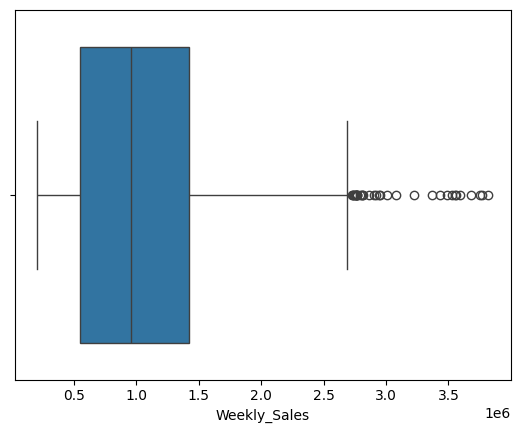

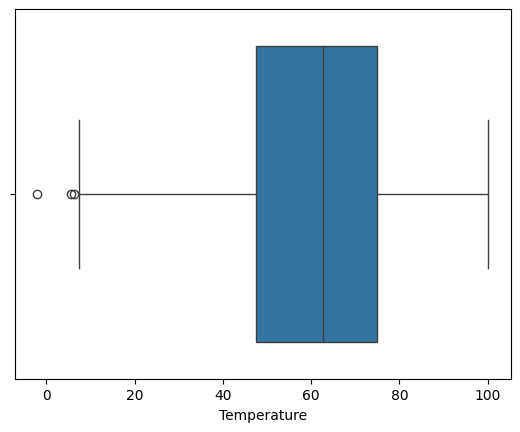

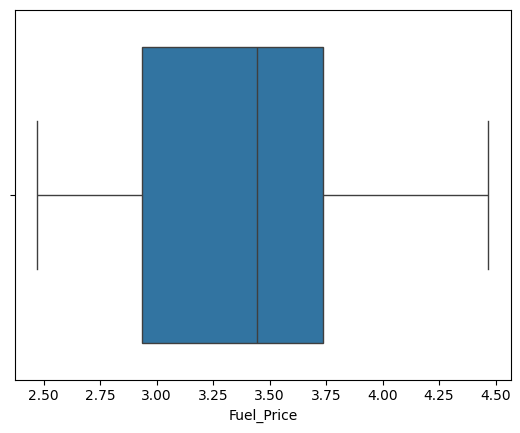

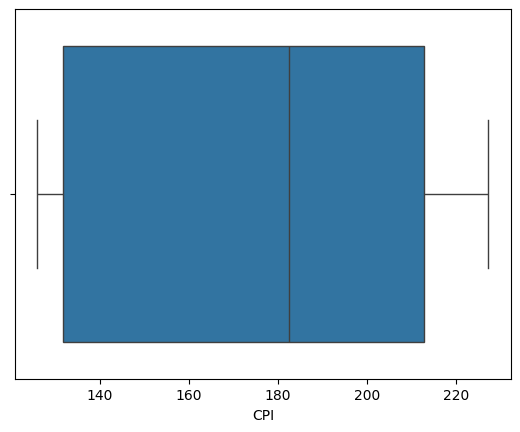

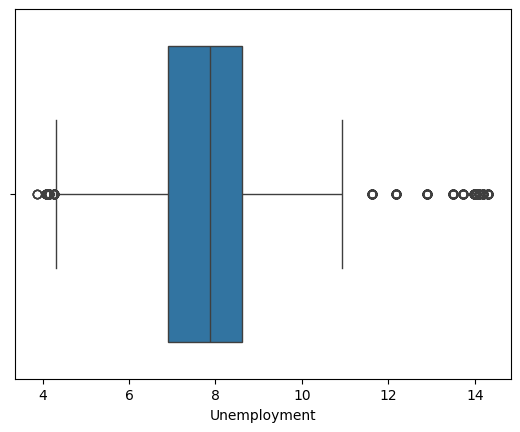

In [12]:
num_cols = df.select_dtypes(include='number').columns.drop(['Store', 'Holiday_Flag'])

for col in num_cols:
    sns.boxplot(x=df[col])
    plt.show()

**a. If the weekly sales are affected by the unemployment rate, if yes - which stores are suffering the most?**

In [13]:
df[['Weekly_Sales','Unemployment']].corr()

,Weekly_Sales,Unemployment
Weekly_Sales,1.000000,-0.106176
Unemployment,-0.106176,1.000000


In [14]:
store_corr = df.groupby('Store').apply(lambda x: x['Weekly_Sales'].corr(x['Unemployment']))

store_corr.sort_values()

/tmp/ipykernel_8186/1340742111.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  store_corr = df.groupby('Store').apply(lambda x: x['Weekly_Sales'].corr(x['Unemployment']))


,0
Store,
38,-0.785290
44,-0.780076
39,-0.384681
42,-0.356355
41,-0.350630
4,-0.337015
17,-0.263600
3,-0.230413
37,-0.221287


In [52]:
# Conclusion:
# Overall, unemployment has a very weak negative impact on weekly sales (correlation = -0.106).
# However, Store 38 and Store 44 are the most affected stores, showing a strong negative relationship between unemployment and sales.

**b. If the weekly sales show a seasonal trend, when and what could be the reason?**

In [15]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

In [16]:
df['Month'] = df['Date'].dt.month

In [17]:
monthly_sales = df.groupby('Month')['Weekly_Sales'].mean()

monthly_sales

,Weekly_Sales
Month,
1,9.238846e+05
2,1.053200e+06
3,1.013309e+06
4,1.026762e+06
5,1.031714e+06
6,1.064325e+06
7,1.031748e+06
8,1.048017e+06
9,9.893353e+05


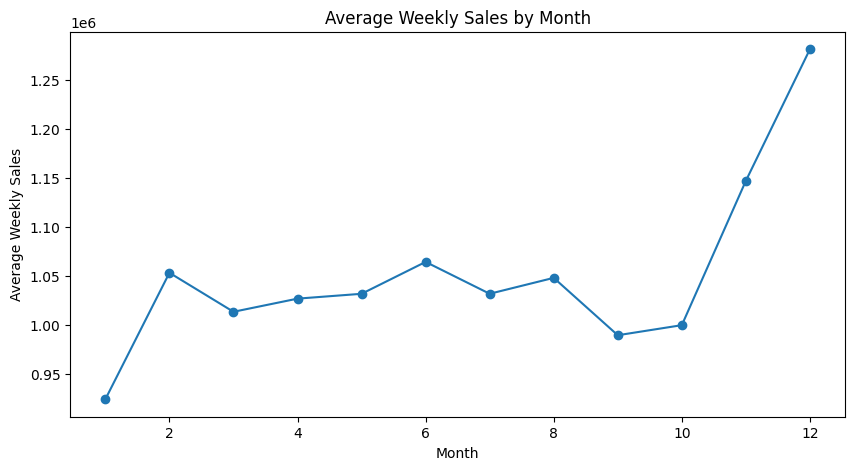

In [18]:
monthly_sales.plot(kind='line',marker='o',figsize=(10,5))
plt.title('Average Weekly Sales by Month')
plt.xlabel('Month')
plt.ylabel('Average Weekly Sales')
plt.show()

In [19]:
df.groupby('Holiday_Flag')['Weekly_Sales'].mean()

,Weekly_Sales
Holiday_Flag,
0,1.041256e+06
1,1.122888e+06


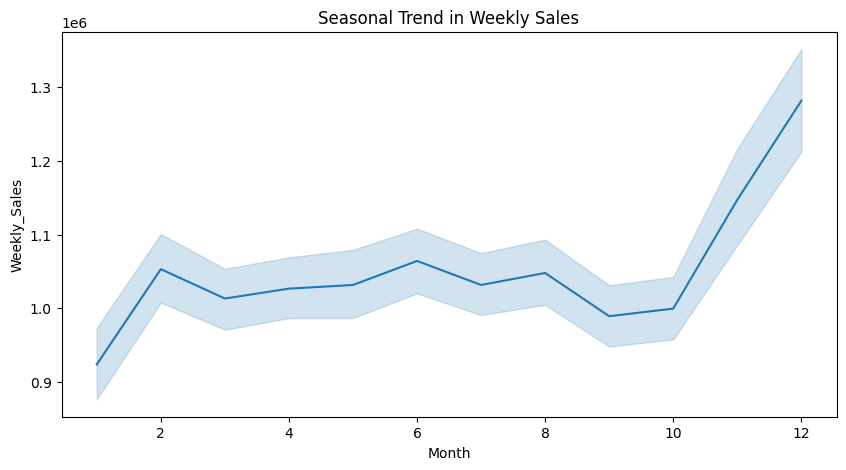

In [20]:
plt.figure(figsize=(10,5))

sns.lineplot(x='Month',y='Weekly_Sales',data=df,estimator='mean')
plt.title('Seasonal Trend in Weekly Sales')
plt.show()

In [ ]:
# Conclusion:
# Weekly sales show a seasonal trend, with the highest sales occurring in November and December.
# This is likely due to holiday shopping, as holiday weeks have higher average sales than non-holiday weeks.

**c. Does temperature affect the weekly sales in any manner?**


In [21]:
df[['Weekly_Sales','Temperature']].corr()

,Weekly_Sales,Temperature
Weekly_Sales,1.00000,-0.06381
Temperature,-0.06381,1.00000


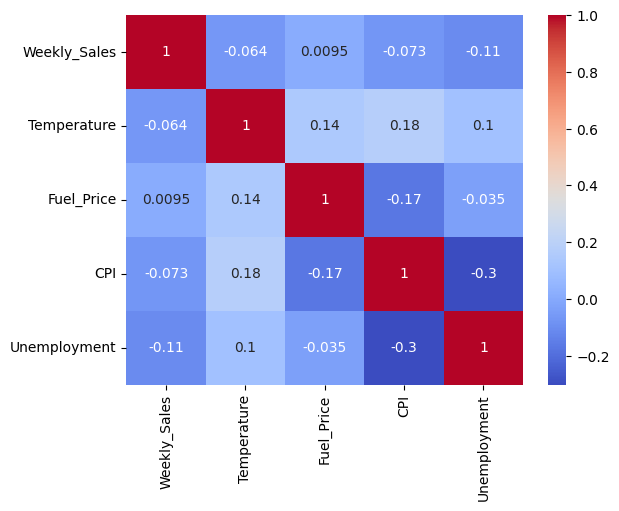

In [22]:
sns.heatmap(df[['Weekly_Sales','Temperature','Fuel_Price','CPI','Unemployment']].corr(),annot=True,cmap='coolwarm')
plt.show()

In [53]:
# Conclusion:
# The correlation between temperature and weekly sales is very weak (-0.0638).
# This indicates that temperature has little to no impact on weekly sales.

**d. How is the Consumer Price index affecting the weekly sales of various stores?**

In [23]:
df[['Weekly_Sales','CPI']].corr()

,Weekly_Sales,CPI
Weekly_Sales,1.000000,-0.072634
CPI,-0.072634,1.000000


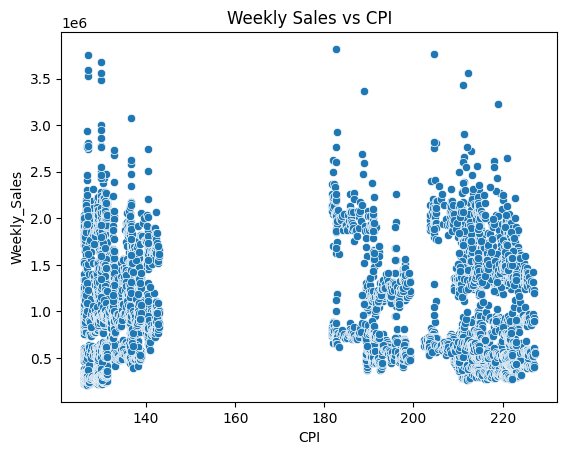

In [24]:
sns.scatterplot(x='CPI',y='Weekly_Sales',data=df)

plt.title('Weekly Sales vs CPI')
plt.show()

In [25]:
store_cpi_corr = df.groupby('Store').apply(lambda x: x['Weekly_Sales'].corr(x['CPI']))

store_cpi_corr.sort_values()

/tmp/ipykernel_8186/514964835.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  store_cpi_corr = df.groupby('Store').apply(lambda x: x['Weekly_Sales'].corr(x['CPI']))


,0
Store,
36,-0.915095
35,-0.424107
14,-0.419755
30,-0.298188
43,-0.285686
27,-0.213082
18,-0.193541
15,-0.174467
21,-0.163649


In [54]:
# Conclusion: CPI has a very weak overall relationship with weekly sales (-0.0726).
# Store 36 is the most negatively affected by CPI, while Stores 38 and 44 show a strong positive relationship with CPI.

**e. Top performing stores according to the historical data.**

In [26]:
store_sales = df.groupby('Store')['Weekly_Sales'].sum()

store_sales.sort_values(ascending=False)

,Weekly_Sales
Store,
20,3.013978e+08
4,2.995440e+08
14,2.889999e+08
13,2.865177e+08
2,2.753824e+08
10,2.716177e+08
27,2.538559e+08
6,2.237561e+08
1,2.224028e+08


In [27]:
top_stores = store_sales.sort_values(ascending=False)

top_stores.head(10)

,Weekly_Sales
Store,
20,3.013978e+08
4,2.995440e+08
14,2.889999e+08
13,2.865177e+08
2,2.753824e+08
10,2.716177e+08
27,2.538559e+08
6,2.237561e+08
1,2.224028e+08


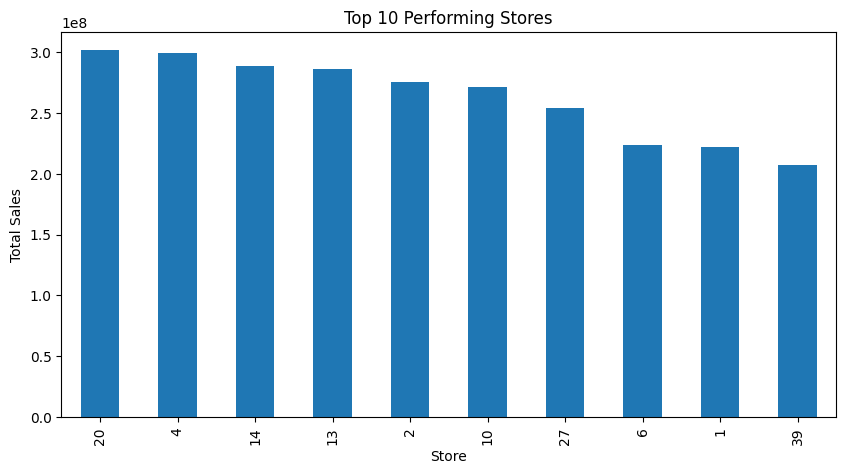

In [28]:
top_stores.head(10).plot(kind='bar',figsize=(10,5))

plt.title('Top 10 Performing Stores')
plt.ylabel('Total Sales')
plt.show()

**f. The worst performing store, and how significant is the difference between the highest and lowest performing stores.**

In [29]:
store_sales = df.groupby('Store')['Weekly_Sales'].sum()

best_store = store_sales.idxmax()

worst_store = store_sales.idxmin()

print("Best Store:", best_store)
print("Worst Store:", worst_store)

Best Store: 20
Worst Store: 33


In [30]:
highest_sales = store_sales.max()

lowest_sales = store_sales.min()

difference = highest_sales - lowest_sales

print(difference)

264237570.49999997


In [31]:
percentage_diff = (difference / highest_sales) * 100

print(percentage_diff)

87.67070533042084


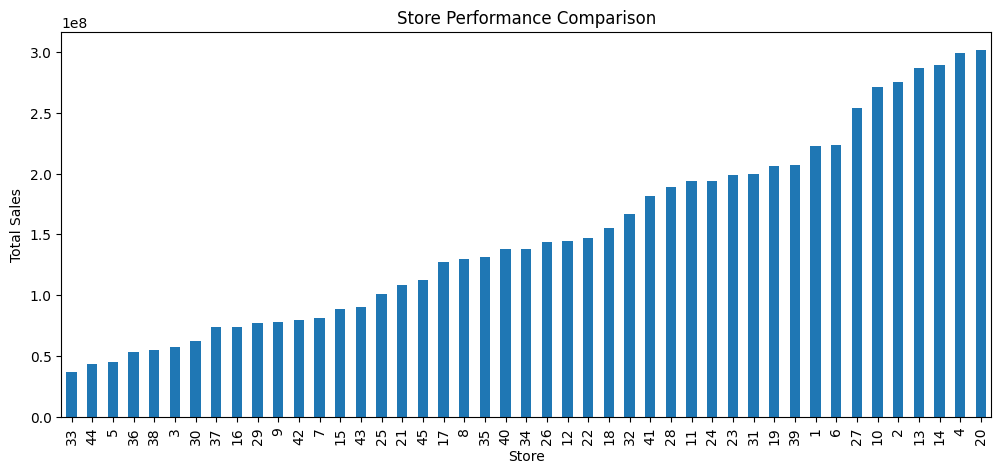

In [32]:
store_sales.sort_values().plot(kind='bar',figsize=(12,5))
plt.title('Store Performance Comparison')
plt.ylabel('Total Sales')

plt.show()

In [55]:
# Conclusion:
# Store 33 is the worst-performing store, while Store 20 is the best-performing store.
# The sales difference between them is very large (264.24 million), showing a significant gap of 87.67% in performance.

# **2. Use predictive modeling techniques to forecast the sales for each store for the next 12weeks.**

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
 8   Month         6435 non-null   int32         
dtypes: datetime64[ns](1), float64(5), int32(1), int64(2)
memory usage: 427.5 KB


In [34]:
df = df.sort_values('Date')

In [35]:
sales = df.groupby('Date')['Weekly_Sales'].sum()

In [36]:
print(sales.head())

Date
2010-02-05    49750740.50
2010-02-12    48336677.63
2010-02-19    48276993.78
2010-02-26    43968571.13
2010-03-05    46871470.30
Name: Weekly_Sales, dtype: float64


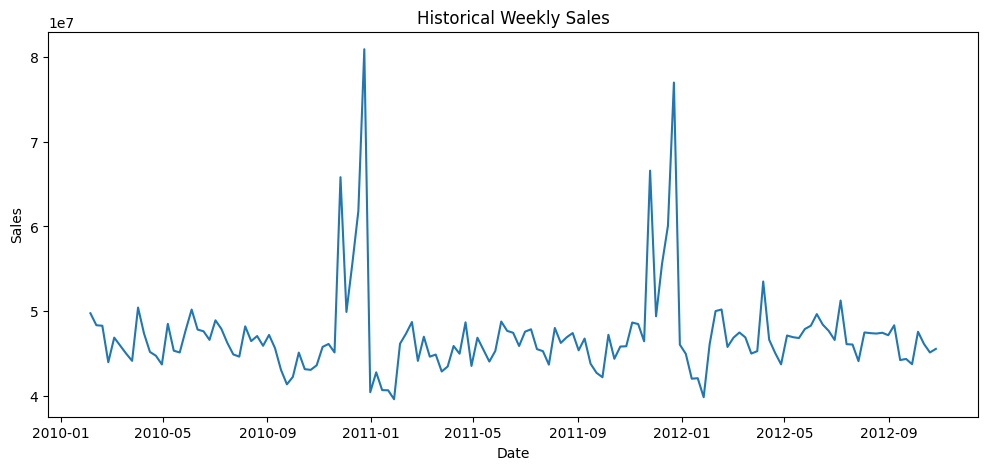

In [37]:
plt.figure(figsize=(12,5))
plt.plot(sales)
plt.title('Historical Weekly Sales')
plt.xlabel('Date')
plt.ylabel('Sales')

plt.show()

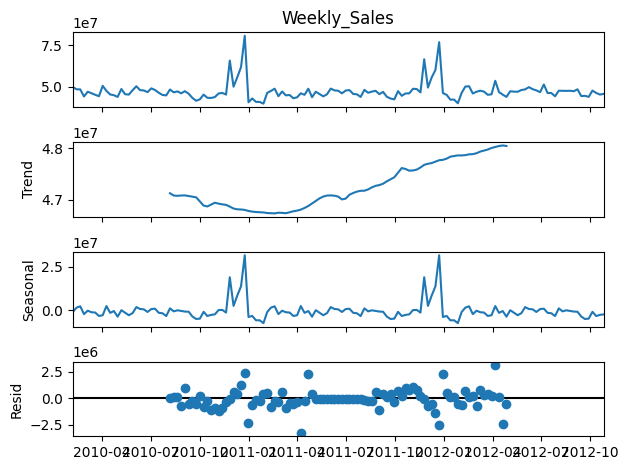

In [38]:
from statsmodels.tsa.seasonal import seasonal_decompose

decompose = seasonal_decompose(sales,model='additive',period=52)
decompose.plot()

plt.show()

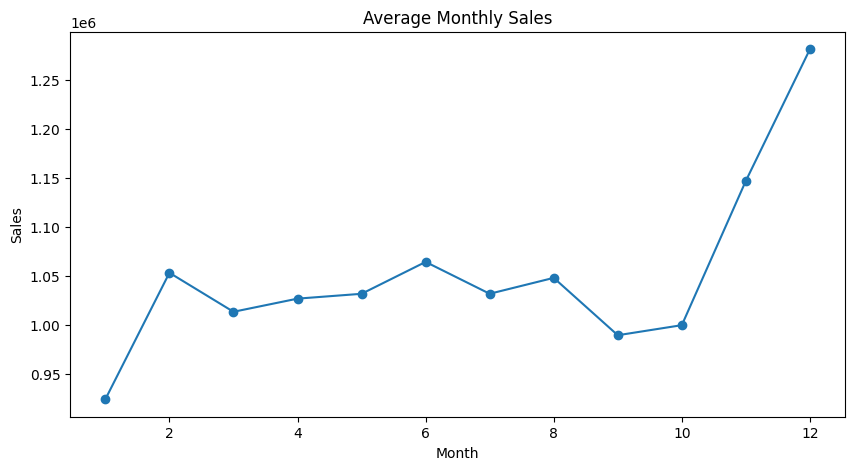

In [39]:
df['Month'] = df['Date'].dt.month

monthly_sales = df.groupby('Month')['Weekly_Sales'].mean()

plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index,monthly_sales.values,marker='o')
plt.title('Average Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Sales')

plt.show()

In [40]:
train = sales[:-12]

test = sales[-12:]

In [41]:
pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 29.5 MB/s eta 0:00:00


In [42]:
from pmdarima import auto_arima

auto_model = auto_arima(train,seasonal=True,m=52,trace=True)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[52] intercept   : AIC=4383.903, Time=22.30 sec
 ARIMA(0,0,0)(0,0,0)[52] intercept   : AIC=4448.784, Time=0.03 sec
 ARIMA(1,0,0)(1,0,0)[52] intercept   : AIC=4413.338, Time=1.22 sec
 ARIMA(0,0,1)(0,0,1)[52] intercept   : AIC=4407.802, Time=0.73 sec
 ARIMA(0,0,0)(0,0,0)[52]             : AIC=5005.121, Time=0.03 sec
 ARIMA(2,0,2)(0,0,1)[52] intercept   : AIC=4397.508, Time=4.44 sec
 ARIMA(2,0,2)(1,0,0)[52] intercept   : AIC=4382.026, Time=6.67 sec
 ARIMA(2,0,2)(0,0,0)[52] intercept   : AIC=4436.570, Time=0.24 sec
 ARIMA(2,0,2)(2,0,0)[52] intercept   : AIC=4384.004, Time=29.95 sec
 ARIMA(2,0,2)(2,0,1)[52] intercept   : AIC=4387.389, Time=43.40 sec
 ARIMA(1,0,2)(1,0,0)[52] intercept   : AIC=4390.491, Time=3.40 sec
 ARIMA(2,0,1)(1,0,0)[52] intercept   : AIC=4392.006, Time=6.56 sec
 ARIMA(3,0,2)(1,0,0)[52] intercept   : AIC=4383.300, Time=8.06 sec
 ARIMA(2,0,3)(1,0,0)[52] intercept   : AIC=4393.382, Time=7.25 sec
 ARIMA(1,0,1)(1,

In [43]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(train,order=(2,0,2),seasonal_order=(1,0,0,52))

result = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:997: UserWarning: Non-stationar

In [44]:
forecast = result.forecast(steps=12)

In [45]:
comparison = pd.DataFrame({
    'Actual': test,
    'Forecast': forecast
})

comparison

,Actual,Forecast
2012-08-10,47403451.04,4.607817e+07
2012-08-17,47354452.05,4.671476e+07
2012-08-24,47447323.60,4.670176e+07
2012-08-31,47159639.43,4.547250e+07
2012-09-07,48330059.31,4.610626e+07
2012-09-14,44226038.65,4.421067e+07
2012-09-21,44354547.11,4.324592e+07
2012-09-28,43734899.40,4.294559e+07
2012-10-05,47566639.31,4.607779e+07
2012-10-12,46128514.25,4.420538e+07


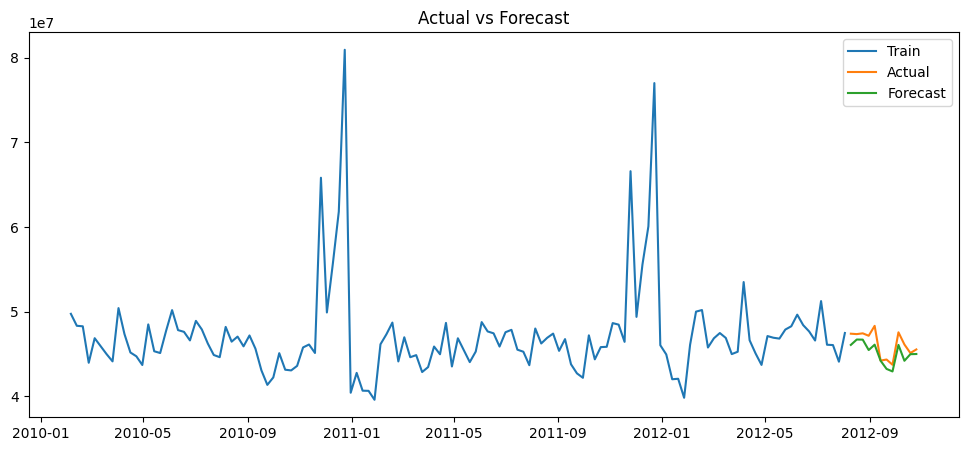

In [46]:
plt.figure(figsize=(12,5))

plt.plot(train.index,train,label='Train')
plt.plot(test.index,test,label='Actual')
plt.plot(forecast.index,forecast,label='Forecast')
plt.legend()
plt.title('Actual vs Forecast')

plt.show()

In [47]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(test,forecast)

print(mae)

1052117.1040474318


In [48]:
final_model = SARIMAX(sales,order=(2,0,2),seasonal_order=(1,0,0,52))

final_result = final_model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:997: UserWarning: Non-stationar

In [49]:
future_forecast = final_result.forecast(steps=12)
future_forecast

,predicted_mean
2012-11-02,4.755953e+07
2012-11-09,4.741271e+07
2012-11-16,4.587478e+07
2012-11-23,5.970212e+07
2012-11-30,4.774498e+07
2012-12-07,5.194522e+07
2012-12-14,5.494171e+07
2012-12-21,6.652271e+07
2012-12-28,4.512528e+07
2013-01-04,4.432135e+07


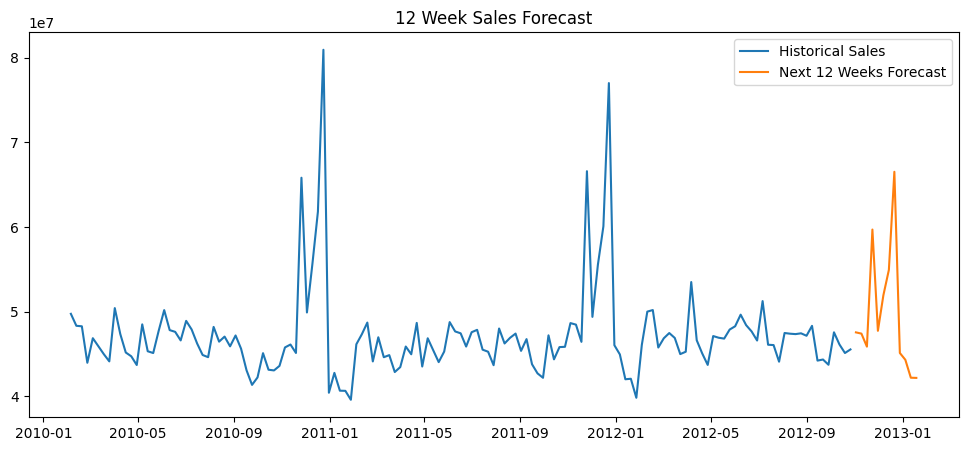

In [50]:
plt.figure(figsize=(12,5))

plt.plot(sales,label='Historical Sales')

plt.plot(future_forecast.index,future_forecast,label='Next 12 Weeks Forecast')
plt.legend()
plt.title('12 Week Sales Forecast')

plt.show()

In [50]:
# Conclusion:
# A SARIMA model was used to forecast sales for the next 12 weeks.
# The forecast follows the historical sales pattern and provides a reasonable estimate of future sales, which can help Walmart with planning and decision-making.